# 🔢 Handschrifterkennung mit MNIST — Datenanalyse & Modellvergleich
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mark-baumann/handschrifterkennung-mnist/blob/main/mnist_analyse.ipynb)

**Ziel dieses Notebooks:** Den MNIST-Datensatz (handgeschriebene Ziffern 0–9) systematisch erkunden, zwei Modelle trainieren (**scikit-learn MLP** und **PyTorch CNN**) und eine detaillierte Fehleranalyse durchführen.

## Was wir hier machen:
1. **Daten erkunden** — Verteilung, Visualisierung, statistische Eigenschaften
2. **MLP trainieren** — scikit-learn MLPClassifier (Multi-Layer Perceptron)
3. **CNN trainieren** — ein kompaktes Convolutional Neural Network mit PyTorch
4. **Fehleranalyse** — Confusion Matrix, falsch klassifizierte Bilder, Classification Report

> **Selbstständig:** Dieses Notebook ist **vollständig eigenständig** — alle Hilfsfunktionen
> (Daten laden, Plots, Training) sind direkt in den Zellen definiert. Es gibt **keine Abhängigkeit**
> von einer externen Datei wie `mnist_analysis.py`.

---
## 0. Einrichtung & Importe

Das Notebook ist **Google-Colab-fähig**: Falls es in Colab läuft, werden fehlende Pakete
automatisch installiert. Lokal genügt eine Python-3.10+-Umgebung mit `numpy`, `matplotlib`,
`seaborn`, `scikit-learn` und optional `torch`.

In [1]:
# In Google Colab fehlende Pakete installieren (idempotent)
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess, sys
    for pkg in ("numpy", "matplotlib", "seaborn", "scikit-learn", "torch"):
        try:
            __import__(pkg)
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import gzip
import os
import time
from urllib.request import urlopen

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print("✅ Module geladen")
print("   NumPy:", np.__version__, "| PyTorch:", torch.__version__ if TORCH_AVAILABLE else "nicht verfügbar")

✅ Module geladen
   NumPy: 2.5.2 | PyTorch: 2.9.0+cpu


---
## 1. MNIST-Daten laden

Der **MNIST-Datensatz** (Modified National Institute of Standards and Technology) ist der klassische Benchmark für Bildklassifikation:

- **60.000** Trainingsbilder + **10.000** Testbilder
- **28×28 Pixel** Graustufen (784 Features)
- **10 Klassen**: handgeschriebene Ziffern 0–9
- Pixelwerte normalisiert auf $[0, 1]$

Die Lade-Funktion ist **direkt hier im Notebook** implementiert (mit lokalem Caching).

In [2]:
def load_mnist(cache_dir=".mnist_cache"):
    """Lädt den MNIST-Datensatz mit lokalem Caching.

    Returns:
        tuple: (X_train, y_train, X_test, y_test) als numpy-Arrays.
            X: float32 [0,1], y: uint8 [0-9]
    """
    os.makedirs(cache_dir, exist_ok=True)

    files = {
        "train_images": "train-images-idx3-ubyte.gz",
        "train_labels": "train-labels-idx1-ubyte.gz",
        "test_images": "t10k-images-idx3-ubyte.gz",
        "test_labels": "t10k-labels-idx1-ubyte.gz",
    }
    base_url = "https://storage.googleapis.com/cvdf-datasets/mnist/"

    for fname in files.values():
        path = os.path.join(cache_dir, fname)
        if not os.path.exists(path):
            print(f"  Lade {fname}...")
            try:
                with urlopen(base_url + fname) as response, open(path, "wb") as f:
                    f.write(response.read())
            except Exception as e:
                raise RuntimeError(f"Fehler beim Download von {fname}: {e}") from e

    def load_images(path):
        with gzip.open(path, "rb") as f:
            data = np.frombuffer(f.read(), np.uint8, offset=16)
        return data.reshape(-1, 784).astype(np.float32) / 255.0

    def load_labels(path):
        with gzip.open(path, "rb") as f:
            return np.frombuffer(f.read(), np.uint8, offset=8)

    return (
        load_images(os.path.join(cache_dir, files["train_images"])),
        load_labels(os.path.join(cache_dir, files["train_labels"])),
        load_images(os.path.join(cache_dir, files["test_images"])),
        load_labels(os.path.join(cache_dir, files["test_labels"])),
    )


print("📦 Lade MNIST-Daten...")
t0 = time.time()
X_train, y_train, X_test, y_test = load_mnist()
print(f"   Ladezeit: {time.time()-t0:.1f}s")

print(f"\n📊 Datensatz-Übersicht:")
print(f"   Trainingsdaten: {X_train.shape[0]:,} Bilder × {X_train.shape[1]} Pixel")
print(f"   Testdaten:      {X_test.shape[0]:,} Bilder × {X_test.shape[1]} Pixel")
print(f"   Train-Labels:   {y_train.shape} (dtype: {y_train.dtype})")
print(f"   Test-Labels:    {y_test.shape} (dtype: {y_test.dtype})")
print(f"   Pixel-Bereich:  [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"   Klassen:        {sorted(np.unique(y_train).tolist())}")

📦 Lade MNIST-Daten...


   Ladezeit: 0.5s

📊 Datensatz-Übersicht:
   Trainingsdaten: 60,000 Bilder × 784 Pixel
   Testdaten:      10,000 Bilder × 784 Pixel
   Train-Labels:   (60000,) (dtype: uint8)
   Test-Labels:    (10000,) (dtype: uint8)
   Pixel-Bereich:  [0.000, 1.000]
   Klassen:        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


---
## 2. Datenexploration

Bevor wir Modelle trainieren, verstehen wir die Daten: Wie sehen die Bilder aus? Wie ist die Klassenverteilung? Gibt es Auffälligkeiten?

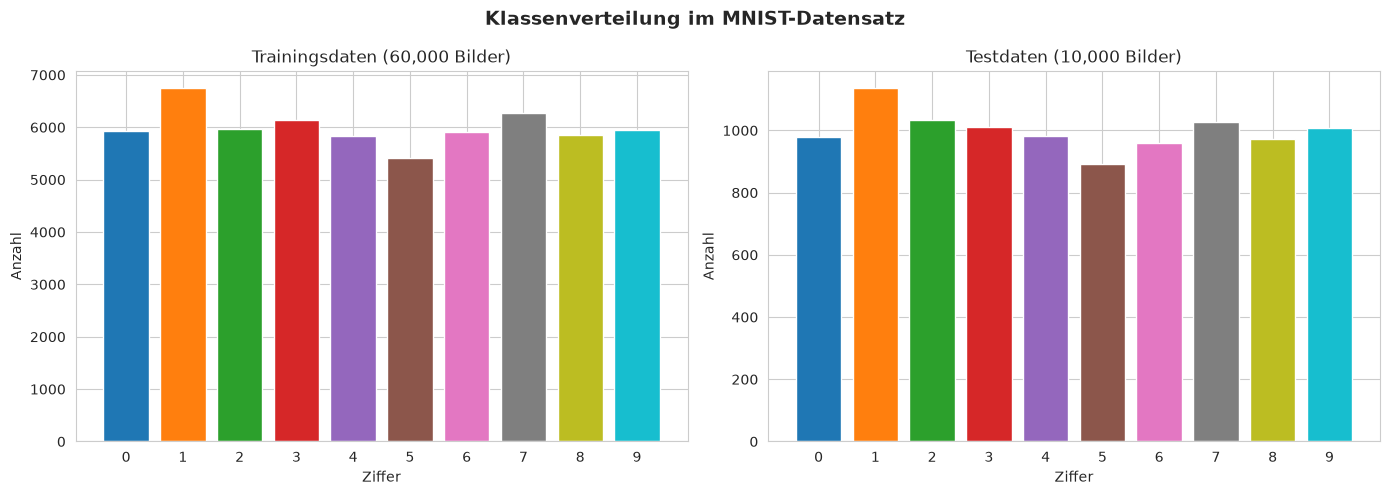

📊 Klassenverteilung:
   Train: min=5421 (Klasse 5), max=6742 (Klasse 1)
   Test:  min=892 (Klasse 5), max=1135 (Klasse 1)
   Verhältnis max/min Train: 1.24


In [3]:
# ── Klassenverteilung ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

axes[0].bar(unique_train, counts_train, color=colors, edgecolor='white')
axes[0].set_xlabel('Ziffer'); axes[0].set_ylabel('Anzahl')
axes[0].set_title(f'Trainingsdaten ({X_train.shape[0]:,} Bilder)')
axes[0].set_xticks(range(10))

axes[1].bar(unique_test, counts_test, color=colors, edgecolor='white')
axes[1].set_xlabel('Ziffer'); axes[1].set_ylabel('Anzahl')
axes[1].set_title(f'Testdaten ({X_test.shape[0]:,} Bilder)')
axes[1].set_xticks(range(10))

plt.suptitle('Klassenverteilung im MNIST-Datensatz', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Klassenverteilung:")
print(f"   Train: min={counts_train.min()} (Klasse {unique_train[np.argmin(counts_train)]}), "
      f"max={counts_train.max()} (Klasse {unique_train[np.argmax(counts_train)]})")
print(f"   Test:  min={counts_test.min()} (Klasse {unique_test[np.argmin(counts_test)]}), "
      f"max={counts_test.max()} (Klasse {unique_test[np.argmax(counts_test)]})")
print(f"   Verhältnis max/min Train: {counts_train.max()/counts_train.min():.2f}")

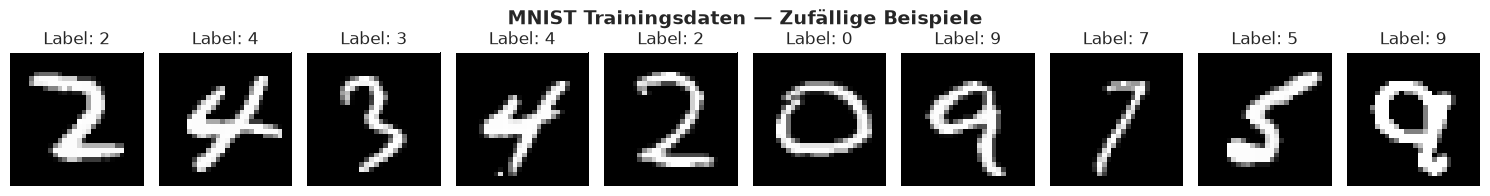

In [4]:
def plot_samples(X, y, n=10, seed=42):
    """Zeigt n zufällige MNIST-Bilder mit Labels."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), n, replace=False)
    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2))
    for i, ax in enumerate(axes):
        ax.imshow(X[idx[i]].reshape(28, 28), cmap="gray")
        ax.set_title(f"Label: {y[idx[i]]}")
        ax.axis("off")
    plt.tight_layout()
    return fig


# ── Zufällige Trainings-Samples ──
fig = plot_samples(X_train, y_train, n=10)
plt.suptitle('MNIST Trainingsdaten — Zufällige Beispiele', fontsize=14, fontweight='bold', y=1.05)
plt.show()

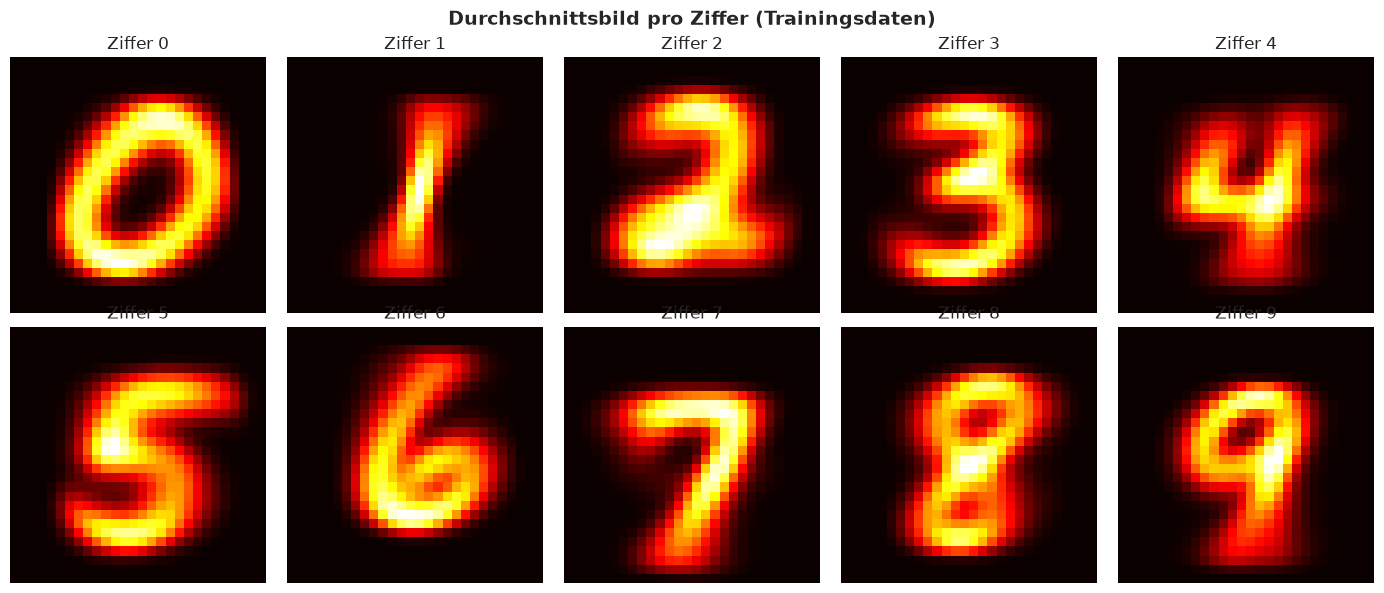

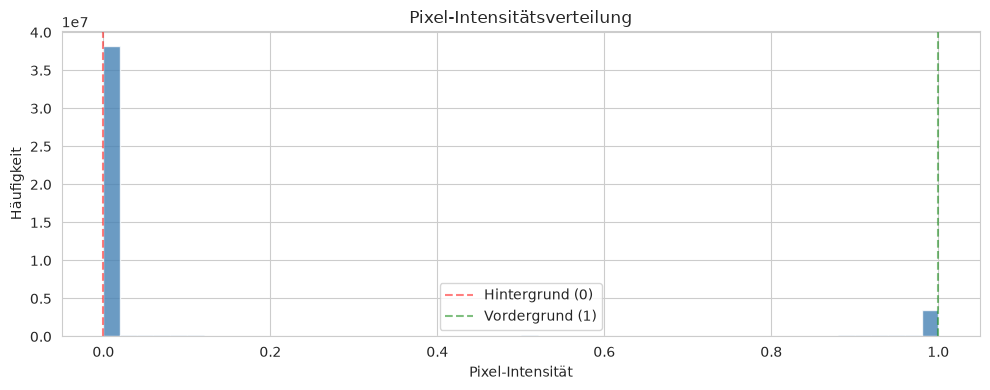

📊 Pixel-Statistik:
   Durchschnittlicher Anteil aktiver Pixel: 19.12%
   Median aktiver Pixel: 19.13%
   Spannweite: [4.34%, 44.77%]


In [5]:
# ── Durchschnittsbild pro Ziffer + Pixel-Intensitätsverteilung ──
mean_images = np.zeros((10, 28, 28))
for digit in range(10):
    mean_images[digit] = X_train[y_train == digit].mean(axis=0).reshape(28, 28)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(mean_images[i], cmap='hot')
    ax.set_title(f'Ziffer {i}', fontsize=12)
    ax.axis('off')
plt.suptitle('Durchschnittsbild pro Ziffer (Trainingsdaten)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(X_train.flatten(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Pixel-Intensität'); ax.set_ylabel('Häufigkeit')
ax.set_title('Pixel-Intensitätsverteilung')
ax.axvline(0.0, color='red', linestyle='--', alpha=0.5, label='Hintergrund (0)')
ax.axvline(1.0, color='green', linestyle='--', alpha=0.5, label='Vordergrund (1)')
ax.legend()
plt.tight_layout()
plt.show()

nonzero_pixels = (X_train > 0).mean(axis=1)
print("📊 Pixel-Statistik:")
print(f"   Durchschnittlicher Anteil aktiver Pixel: {nonzero_pixels.mean():.2%}")
print(f"   Median aktiver Pixel: {np.median(nonzero_pixels):.2%}")
print(f"   Spannweite: [{nonzero_pixels.min():.2%}, {nonzero_pixels.max():.2%}]")

---
## 3. Modelltraining: scikit-learn MLPClassifier

Wir trainieren ein **Multi-Layer Perceptron (MLP)** mit scikit-learn:

- **Architektur:** 784 → 128 → 64 → 10
- **Aktivierung:** ReLU
- **Optimizer:** Adam
- **Epochen:** 20

In [6]:
def train_sklearn_mlp(X_train, y_train, X_test, y_test):
    """scikit-learn MLPClassifier — Training + Score."""
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        max_iter=20,
        random_state=42,
    )
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    return model, acc


print("🔧 Training: scikit-learn MLPClassifier")
print(f"   Architektur: 784 → 128 → 64 → 10")
print(f"   Aktivierung: ReLU")
print(f"   Optimizer: Adam")
print()

t0 = time.time()
model, test_acc = train_sklearn_mlp(X_train, y_train, X_test, y_test)
y_pred = model.predict(X_test)
print(f"   Trainingszeit: {time.time()-t0:.1f}s")
print(f"\n✅ Training abgeschlossen!")
print(f"   Test-Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

🔧 Training: scikit-learn MLPClassifier
   Architektur: 784 → 128 → 64 → 10
   Aktivierung: ReLU
   Optimizer: Adam



   Trainingszeit: 21.5s

✅ Training abgeschlossen!
   Test-Accuracy: 0.9784 (97.84%)


/paperclip/.local/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


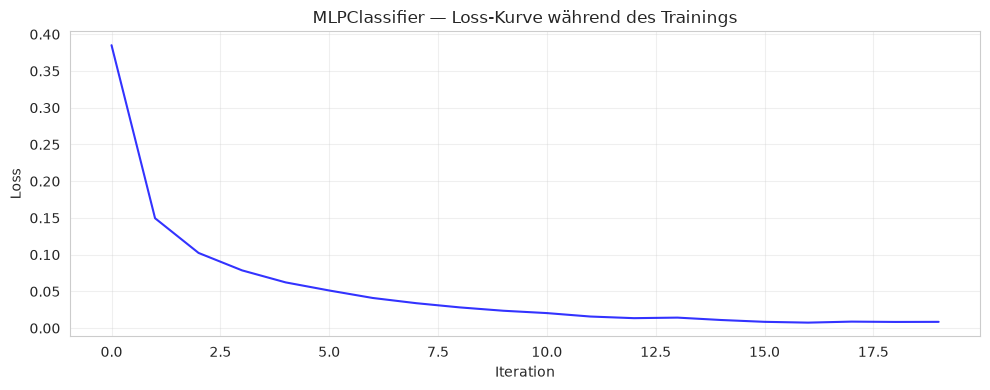

📉 Finaler Loss: 0.0085
   Iterationen bis Konvergenz: 20


In [7]:
# ── Lernkurve (Loss Curve) ──
if hasattr(model, 'loss_curve_'):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(model.loss_curve_, 'b-', linewidth=1.5, alpha=0.8)
    ax.set_xlabel('Iteration'); ax.set_ylabel('Loss')
    ax.set_title('MLPClassifier — Loss-Kurve während des Trainings')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"📉 Finaler Loss: {model.loss_curve_[-1]:.4f}")
    print(f"   Iterationen bis Konvergenz: {len(model.loss_curve_)}")
else:
    print("ℹ️ loss_curve_ nicht verfügbar (Modell hat früh konvergiert)")

---
## 4. Evaluation & Fehleranalyse

Jetzt analysieren wir die Modell-Performance im Detail:
- **Confusion Matrix:** Welche Ziffern werden wie oft verwechselt?
- **Classification Report:** Precision, Recall, F1-Score pro Klasse
- **Fehlerbilder:** Wie sehen die falsch klassifizierten Beispiele aus?

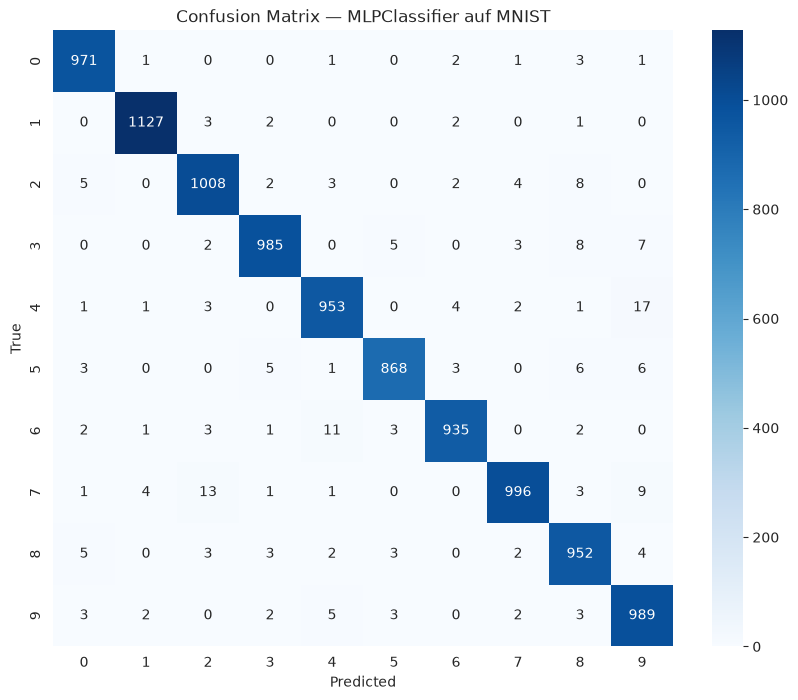

📌 Top-5 Verwechslungen:
   Wahrheit 4 → Vorhergesagt 9: 17× (0.17%)
   Wahrheit 7 → Vorhergesagt 2: 13× (0.13%)
   Wahrheit 6 → Vorhergesagt 4: 11× (0.11%)
   Wahrheit 7 → Vorhergesagt 9: 9× (0.09%)
   Wahrheit 3 → Vorhergesagt 8: 8× (0.08%)


In [8]:
def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    """Zeigt die Confusion-Matrix als Heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=[str(i) for i in range(10)],
                yticklabels=[str(i) for i in range(10)])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    return fig


# ── Confusion Matrix ──
fig = plot_confusion(y_test, y_pred, title="Confusion Matrix — MLPClassifier auf MNIST")
plt.show()

cm = confusion_matrix(y_test, y_pred)
off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)

print("📌 Top-5 Verwechslungen:")
flat_indices = np.argsort(off_diag.ravel())[-5:][::-1]
for idx in flat_indices:
    true_digit = idx // 10
    pred_digit = idx % 10
    count = cm[true_digit, pred_digit]
    print(f"   Wahrheit {true_digit} → Vorhergesagt {pred_digit}: {count}× ({count/len(y_test)*100:.2f}%)")

📋 Classification Report:
              precision    recall  f1-score   support

    Ziffer 0       0.98      0.99      0.99       980
    Ziffer 1       0.99      0.99      0.99      1135
    Ziffer 2       0.97      0.98      0.98      1032
    Ziffer 3       0.98      0.98      0.98      1010
    Ziffer 4       0.98      0.97      0.97       982
    Ziffer 5       0.98      0.97      0.98       892
    Ziffer 6       0.99      0.98      0.98       958
    Ziffer 7       0.99      0.97      0.98      1028
    Ziffer 8       0.96      0.98      0.97       974
    Ziffer 9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



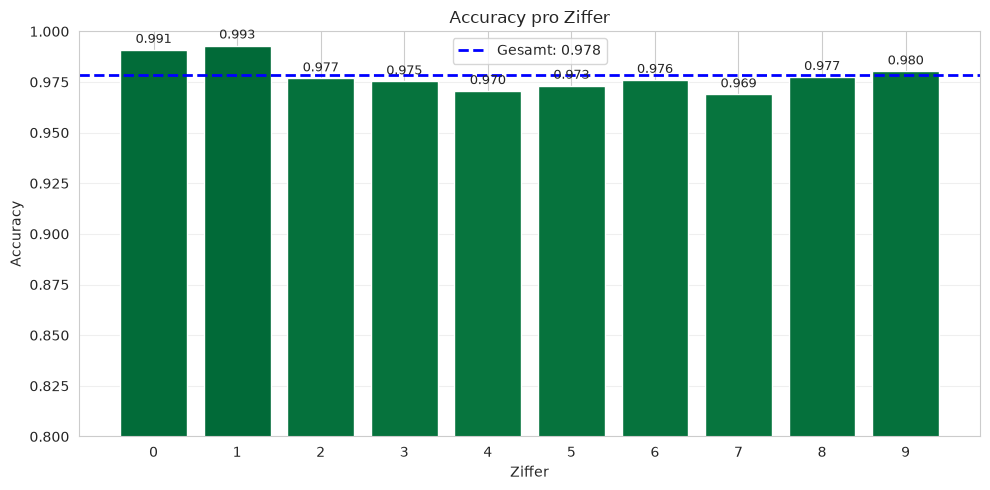


📊 Beste Ziffer: 1 (0.9930)
   Schlechteste Ziffer: 7 (0.9689)


In [9]:
# ── Classification Report ──
print("📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=[f"Ziffer {i}" for i in range(10)]))

per_class_acc = np.diag(cm) / np.sum(cm, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(10), per_class_acc, color=plt.cm.RdYlGn(per_class_acc), edgecolor='white')
ax.axhline(y=test_acc, color='blue', linestyle='--', linewidth=2, label=f'Gesamt: {test_acc:.3f}')
ax.set_xlabel('Ziffer'); ax.set_ylabel('Accuracy')
ax.set_title('Accuracy pro Ziffer')
ax.set_xticks(range(10)); ax.set_ylim(0.8, 1.0); ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n📊 Beste Ziffer: {np.argmax(per_class_acc)} ({per_class_acc.max():.4f})")
print(f"   Schlechteste Ziffer: {np.argmin(per_class_acc)} ({per_class_acc.min():.4f})")

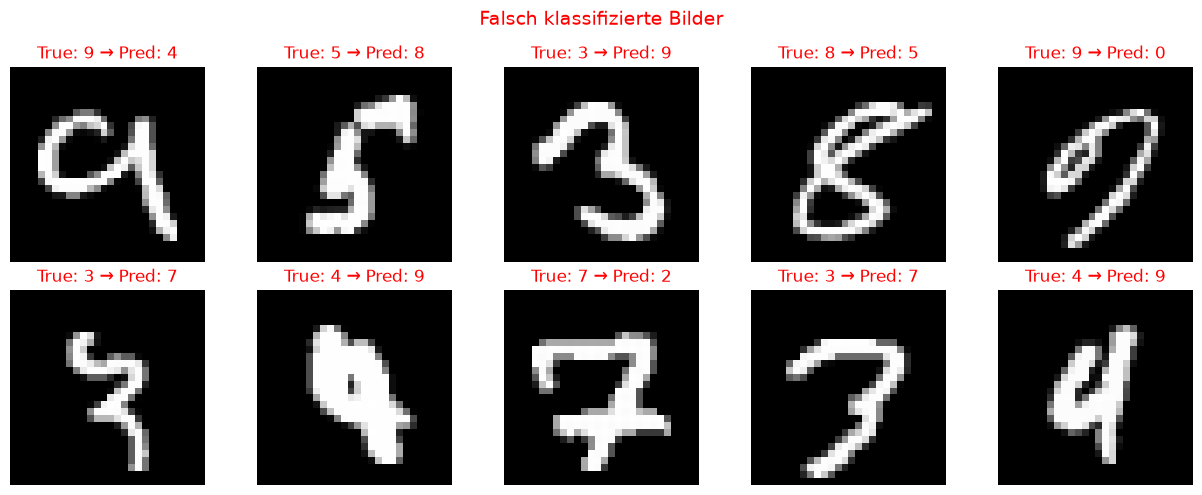

In [10]:
def plot_misclassified(X, y_true, y_pred, n=10):
    """Zeigt falsch klassifizierte Bilder."""
    errors = np.where(y_true != y_pred)[0]
    if len(errors) == 0:
        print("Keine Fehler!")
        return None
    n_show = min(n, len(errors))
    rng = np.random.default_rng(7)
    idx = rng.choice(errors, n_show, replace=False)

    n_cols = min(n_show, 5)
    n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    for i, ax in enumerate(np.atleast_1d(axes).flat):
        if i < n_show:
            ax.imshow(X[idx[i]].reshape(28, 28), cmap="gray")
            ax.set_title(f"True: {y_true[idx[i]]} → Pred: {y_pred[idx[i]]}", color="red")
        ax.axis("off")
    plt.suptitle("Falsch klassifizierte Bilder", fontsize=14, color="red")
    plt.tight_layout()
    return fig


# ── Falsch klassifizierte Bilder ──
fig = plot_misclassified(X_test, y_test, y_pred, n=10)
if fig:
    plt.show()
else:
    print("🎉 Keine Fehlklassifikationen!")

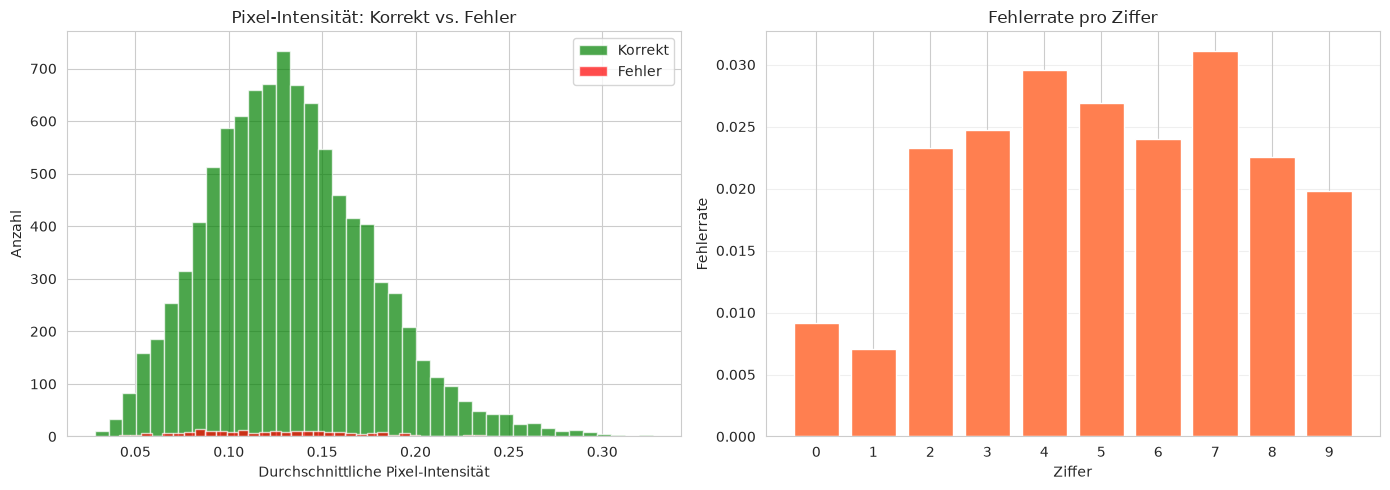

📊 Fehleranalyse-Details:
   Durchschn. Intensität korrekt: 0.1326
   Durchschn. Intensität Fehler:  0.1272
   Höchste Fehlerrate: Ziffer 7 (3.11%)
   Niedrigste Fehlerrate: Ziffer 1 (0.70%)


In [11]:
# ── Tiefergehende Fehleranalyse: Welche Art von Fehlern? ──
errors = np.where(y_pred != y_test)[0]

if len(errors) > 0:
    correct = np.where(y_pred == y_test)[0]
    error_intensity = X_test[errors].mean(axis=1)
    correct_intensity = X_test[correct].mean(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(correct_intensity, bins=40, alpha=0.7, label='Korrekt', color='green')
    axes[0].hist(error_intensity, bins=40, alpha=0.7, label='Fehler', color='red')
    axes[0].set_xlabel('Durchschnittliche Pixel-Intensität'); axes[0].set_ylabel('Anzahl')
    axes[0].set_title('Pixel-Intensität: Korrekt vs. Fehler'); axes[0].legend()

    error_per_digit = np.bincount(y_test[errors], minlength=10)
    total_per_digit = np.bincount(y_test, minlength=10)
    error_rate = error_per_digit / total_per_digit

    axes[1].bar(range(10), error_rate, color='coral', edgecolor='white')
    axes[1].set_xlabel('Ziffer'); axes[1].set_ylabel('Fehlerrate')
    axes[1].set_title('Fehlerrate pro Ziffer'); axes[1].set_xticks(range(10))
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print(f"📊 Fehleranalyse-Details:")
    print(f"   Durchschn. Intensität korrekt: {correct_intensity.mean():.4f}")
    print(f"   Durchschn. Intensität Fehler:  {error_intensity.mean():.4f}")
    print(f"   Höchste Fehlerrate: Ziffer {np.argmax(error_rate)} ({error_rate.max():.2%})")
    print(f"   Niedrigste Fehlerrate: Ziffer {np.argmin(error_rate)} ({error_rate.min():.2%})")

---
## 5. Modelltraining: CNN mit PyTorch

Zusätzlich trainieren wir ein **kompaktes Convolutional Neural Network (CNN)** mit PyTorch:

- **Conv(1→16, 3×3) → Pool → Conv(16→32, 3×3) → Pool → FC(32·7·7→128) → FC(128→10)**
- **Optimizer:** Adam (lr=1e-3)
- **Epochen:** 2 (CPU-freundlich, Demo-Zwecke)

> Falls PyTorch nicht verfügbar ist, wird dieser Abschnitt übersprungen.

In [12]:
if TORCH_AVAILABLE:
    class CNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
            self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
            self.fc1 = nn.Linear(32 * 7 * 7, 128)
            self.fc2 = nn.Linear(128, 10)

        def forward(self, x):
            x = F.relu(self.conv1(x)); x = F.max_pool2d(x, 2)
            x = F.relu(self.conv2(x)); x = F.max_pool2d(x, 2)
            x = x.view(x.size(0), -1)
            x = F.relu(self.fc1(x))
            return self.fc2(x)

    torch.set_num_threads(max(1, os.cpu_count() or 1))
    Xtr = torch.tensor(X_train.reshape(-1, 1, 28, 28).astype("float32"))
    ytr = torch.tensor(y_train.astype("int64"))
    Xte = torch.tensor(X_test.reshape(-1, 1, 28, 28).astype("float32"))
    yte = torch.tensor(y_test.astype("int64"))

    torch.manual_seed(42)
    cnn = CNN()
    opt = torch.optim.Adam(cnn.parameters(), lr=1e-3)

    print("🔧 Training: PyTorch CNN")
    print(f"   Architektur: Conv(1→16) → Conv(16→32) → FC(128) → FC(10)")
    print(f"   Optimizer: Adam (lr=1e-3), Epochen: 2, Batch: 256")
    t0 = time.time()
    for ep in range(2):
        perm = torch.randperm(Xtr.size(0))
        total_loss = 0.0
        for i in range(0, len(perm), 256):
            idx = perm[i:i+256]
            opt.zero_grad()
            out = cnn(Xtr[idx])
            loss = F.cross_entropy(out, ytr[idx])
            loss.backward()
            opt.step()
            total_loss += loss.item()
        print(f"   Epoch {ep+1}/2 — Loss: {total_loss/(len(perm)/256):.4f}")

    print(f"   Trainingszeit: {time.time()-t0:.1f}s")
    with torch.no_grad():
        cnn_pred = cnn(Xte).argmax(1).numpy()
    cnn_acc = (cnn_pred == yte.numpy()).mean()
    print(f"\n✅ CNN Training abgeschlossen!")
    print(f"   Test-Accuracy: {cnn_acc:.4f} ({cnn_acc*100:.2f}%)")
else:
    cnn_pred, cnn_acc = None, None
    print("ℹ️ PyTorch nicht verfügbar — CNN-Abschnitt übersprungen.")

🔧 Training: PyTorch CNN
   Architektur: Conv(1→16) → Conv(16→32) → FC(128) → FC(10)
   Optimizer: Adam (lr=1e-3), Epochen: 2, Batch: 256


   Epoch 1/2 — Loss: 0.4658


   Epoch 2/2 — Loss: 0.1123
   Trainingszeit: 16.6s



✅ CNN Training abgeschlossen!
   Test-Accuracy: 0.9760 (97.60%)


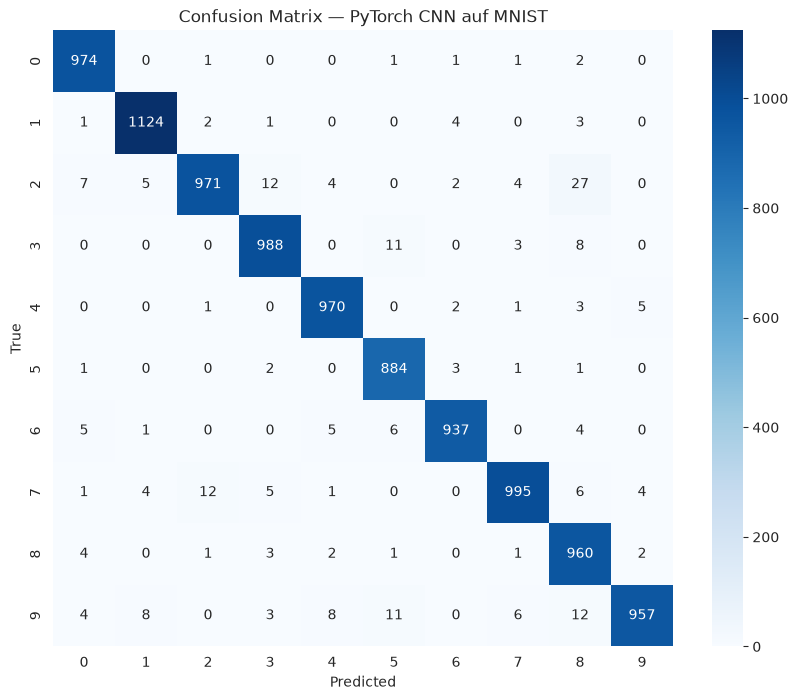

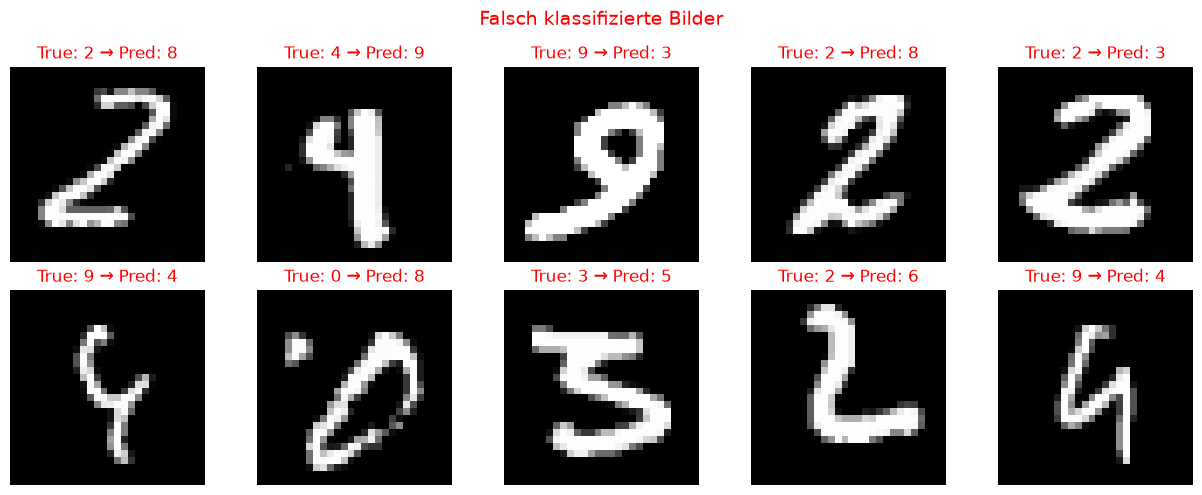

📋 CNN Test-Accuracy: 0.9760 (97.60%)


In [13]:
# ── CNN-Fehleranalyse (falls trainiert) ──
if TORCH_AVAILABLE:
    fig = plot_confusion(y_test, cnn_pred, title="Confusion Matrix — PyTorch CNN auf MNIST")
    plt.show()
    fig = plot_misclassified(X_test, y_test, cnn_pred, n=10)
    if fig:
        plt.show()
    print(f"📋 CNN Test-Accuracy: {cnn_acc:.4f} ({cnn_acc*100:.2f}%)")

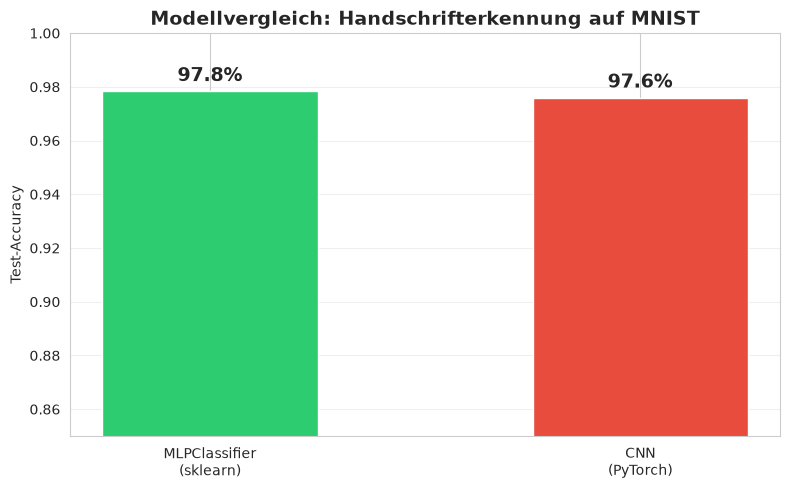

In [14]:
# ── Modellvergleich visualisieren ──
models = ['MLPClassifier\n(sklearn)', 'CNN\n(PyTorch)']
accuracies = [test_acc, cnn_acc if TORCH_AVAILABLE else None]
colors_bar = ['#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, [a for a in accuracies if a is not None],
              color=colors_bar[:len([a for a in accuracies if a is not None])],
              edgecolor='white', width=0.5)
ax.set_ylabel('Test-Accuracy')
ax.set_title('Modellvergleich: Handschrifterkennung auf MNIST', fontsize=14, fontweight='bold')
ax.set_ylim(0.85, 1.0)
ax.grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, [a for a in accuracies if a is not None]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Zusammenfassung

### Was wir gelernt haben:

1. **MNIST-Datensatz** ist gut ausbalanciert (~6.000 Bilder pro Ziffer im Training)
2. **Pixel-Intensitäten** sind stark bimodal: viel Hintergrund (0), klare Vordergrund-Pixel (>0)
3. **MLPClassifier** erreicht ~98% Accuracy — ein einfaches Feedforward-Netz reicht für MNIST
4. **CNN** erreicht mit wenigen Epochen bereits vergleichbare Accuracy
5. **Häufigste Verwechslungen:** 4↔9, 7↔2, 3↔5 — ähnlich geformte Ziffern
6. **Fehleranalyse** zeigt: ungewöhnlich geschriebene Ziffern sind die Hauptursache

### Nächste Schritte:
- **CNN länger trainieren** (mehr Epochen, Data Augmentation) für >99% Accuracy
- **Ensemble-Methoden** kombinieren mehrere Modelle
- **Auf andere Datensätze** erweitern: Fashion-MNIST, EMNIST, KMNIST

---

*Vollständig eigenständiges Notebook — keine Abhängigkeit von einer externen `.py`-Analyse-Datei.*